<a href="https://colab.research.google.com/github/emailtosanj/IBM_RAG_Agentic_AI_PC/blob/development/1_biketrain_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2> Forcasting Demand on Bike Sharing </h2>
<h3> This consist of 3 notebook  </h3>
    <h4> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 1 biketrain-data_preparation.ipynb    </h4>
    <h4> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 2 biketrain-xgboost_training.ipynb    </h4>
    <h4> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3 biketrain-xgboost_prediction.ipynb  </h4>

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Mount the drive
import google.colab as colab
colab.drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
import os
file_dir = '/content/drive/MyDrive/great_learning_ai_on_cloud/Introduction_to_AI_on_cloud/'
os.listdir(file_dir)


['1-biketrain-data_preparation.ipynb',
 'Introduction to AI on Cloud.docx',
 'Introduction_to_AI_on_Cloud.pdf',
 'AI on Cloud_Introduction to Cloud.pdf',
 'GL_ML_Services_v1.5.pptx',
 'test.csv',
 'train.csv',
 '3-biketrain-xgboost_prediction.ipynb',
 'bike_train.csv',
 'bike_all.csv',
 'bike_validation.csv',
 'bike_test.csv',
 'bike_train_column_list.txt',
 '2-biketrain-xgboost_training.ipynb']

<h4>To download dataset, sign-in and download from this link: https://www.kaggle.com/c/bike-sharing-demand/data</h4>
<br>
Input Features (X): ['season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'dayofweek','hour']<br>
Target Feature (Y): ['count']<br>

<b>Objective:</b> <quote>You are provided hourly rental data spanning two years (2011 & 2012).

<b> Training set </b> :- First 19 days of each month [ Jan 1-19, Feb 1-19 etc],

<b> Test set is  </b> :- 20th to the end of the month [Jan 20-30, feb 20-28 etc.].

You must predict the total count of bikes rented during each hour covered by the test set </quote>

In [6]:
# Column is appended to the dataset at the end of this notebook.
columns = ['count', 'season', 'holiday', 'workingday', 'weather', 'temp',
           'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'dayofweek','hour']

In [7]:
# parse_dates=['datetime'] is to  convert the "datetime" to date field.
df      =  pd.read_csv(file_dir+'train.csv', parse_dates=['datetime']) # parse_dates list gets the datatype from object to datetime64[ns]
df_test =  pd.read_csv(file_dir+'test.csv',  parse_dates=['datetime'])

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


None

In [8]:
# delete this - data exploration.
#df1 =  pd.read_csv('bike_validation_del.csv') #,  parse_dates=['datetime'])
#df1.head()

In [9]:
# "Row_no 430": 2011-01-19 (Jan), "Row_no 431": 2011-02-01 (Feb)
df.iloc[425:435,]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
425,2011-01-19 18:00:00,1,0,1,1,13.94,15.910,61,19.0012,5,156,161
426,2011-01-19 19:00:00,1,0,1,1,13.12,14.395,57,27.9993,4,108,112
427,2011-01-19 20:00:00,1,0,1,1,13.12,15.150,49,19.9995,2,74,76
428,2011-01-19 21:00:00,1,0,1,1,13.12,14.395,49,27.9993,4,55,59
429,2011-01-19 22:00:00,1,0,1,1,12.30,15.150,52,11.0014,6,53,59
430,2011-01-19 23:00:00,1,0,1,1,12.30,13.635,52,31.0009,1,27,28
431,2011-02-01 00:00:00,1,0,1,2,6.56,9.090,64,7.0015,2,6,8
432,2011-02-01 01:00:00,1,0,1,2,6.56,9.090,69,7.0015,0,3,3
433,2011-02-01 02:00:00,1,0,1,2,6.56,11.365,69,0.0000,0,2,2
434,2011-02-01 03:00:00,1,0,1,2,6.56,11.365,69,0.0000,0,2,2


In [10]:
# first 5 rows of test dataset
df_test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [11]:
# We need to convert datetime to numeric for training.
# Let's extract key features into separate numeric columns
def add_features(df):
    df['year']      = df['datetime'].dt.year
    df['month']     = df['datetime'].dt.month
    df['day']       = df['datetime'].dt.day
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['hour']      = df['datetime'].dt.hour

In [12]:
add_features(df)
add_features(df_test)

In [13]:
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,1,1,5,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,1,1,5,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,1,1,5,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,1,1,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,2,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,2,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,2,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,2,22


In [14]:
df.dtypes

,0
datetime,datetime64[ns]
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [15]:
df1 = df.copy()
# Correlation - how strongly features are related to the "count" (output); value ranges from (0[no corr] - 1 [clone])
df1.corr()['count']

,count
datetime,0.310187
season,0.163439
holiday,-0.005393
workingday,0.011594
weather,-0.128655
temp,0.394454
atemp,0.389784
humidity,-0.317371
windspeed,0.101369
casual,0.690414


In [16]:
# Everyday is seperated in hours and take average of bike sharing count in those hours.
group_hour = df.groupby(['hour'])
average_by_hour = group_hour['count'].mean()

In [17]:
#delete this line ... data exploration.
#group_hour = df.groupby(['month'])
#average_by_hour = group_hour['count'].mean()

In [18]:
print (average_by_hour)

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: count, dtype: float64


Text(0.5, 1.0, 'Rental Count Average by hour')

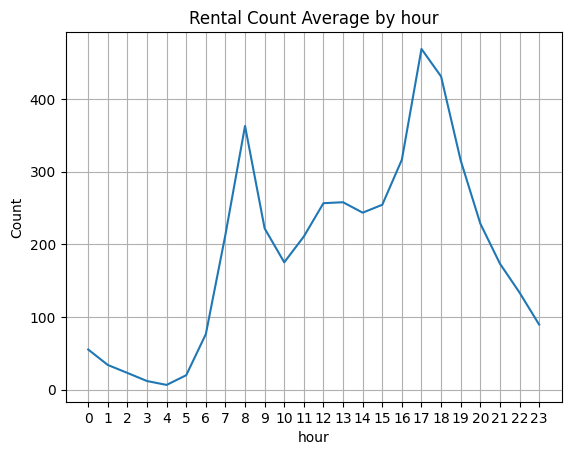

In [19]:
plt.plot(average_by_hour.index,average_by_hour)
plt.xlabel('hour')
plt.ylabel('Count')
plt.xticks(np.arange(24))
plt.grid(True)
plt.title('Rental Count Average by hour')

In [20]:
group_year_hour = df.groupby(['year','hour'])

In [21]:
average_year_hour = group_year_hour['count'].mean()
type(average_year_hour)

pandas.core.series.Series

In [22]:
print(average_year_hour)

year  hour
2011  0        43.563877
      1        26.831858
      2        19.307692
      3        10.056872
      4         5.255814
      5        14.517857
      6        57.519824
      7       157.110132
      8       264.973568
      9       164.488987
      10      131.867841
      11      156.577093
      12      192.188596
      13      191.991228
      14      182.486842
      15      187.701754
      16      236.907895
      17      353.855263
      18      322.043860
      19      236.017544
      20      173.324561
      21      134.118421
      22      103.833333
      23       69.605263
2012  0        66.662281
      1        40.824561
      2        26.396476
      3        13.373874
      4         7.497797
      5        24.925439
      6        94.916667
      7       268.877193
      8       460.135965
      9       278.820175
      10      218.127193
      11      264.535088
      12      320.828947
      13      323.583333
      14      304.399123
      15      

In [23]:
for year in average_year_hour.index.levels[0]:
    print (year)
    print(average_year_hour[year])

2011
hour
0      43.563877
1      26.831858
2      19.307692
3      10.056872
4       5.255814
5      14.517857
6      57.519824
7     157.110132
8     264.973568
9     164.488987
10    131.867841
11    156.577093
12    192.188596
13    191.991228
14    182.486842
15    187.701754
16    236.907895
17    353.855263
18    322.043860
19    236.017544
20    173.324561
21    134.118421
22    103.833333
23     69.605263
Name: count, dtype: float64
2012
hour
0      66.662281
1      40.824561
2      26.396476
3      13.373874
4       7.497797
5      24.925439
6      94.916667
7     268.877193
8     460.135965
9     278.820175
10    218.127193
11    264.535088
12    320.828947
13    323.583333
14    304.399123
15    320.894737
16    395.837719
17    583.675439
18    539.675439
19    394.539474
20    283.710526
21    212.622807
22    163.320175
23    109.412281
Name: count, dtype: float64


In [24]:
print(average_year_hour.index.levels[0])

Index([2011, 2012], dtype='int32', name='year')


Text(0.5, 1.0, 'Rental Count Average by Year,Hour')

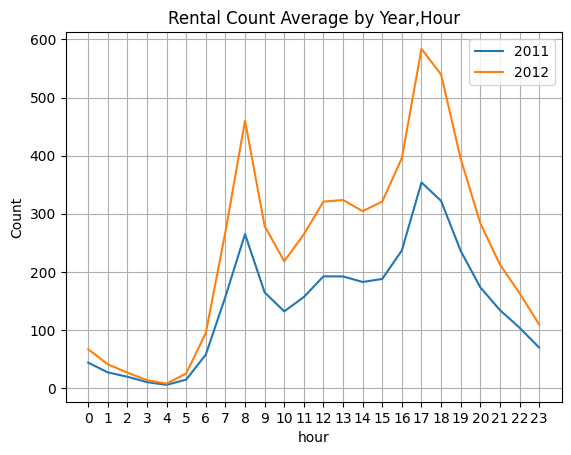

In [25]:
for year in average_year_hour.index.levels[0]:
    #print (year)
    #print(average_year_hour[year])
    plt.plot(average_year_hour[year].index,average_year_hour[year],label=year)

plt.legend()
plt.xlabel('hour')
plt.ylabel('Count')
plt.xticks(np.arange(24))
plt.grid(True)
plt.title('Rental Count Average by Year,Hour')

In [26]:
group_workingday_hour = df.groupby(['workingday','hour'])

In [27]:
average_workingday_hour = group_workingday_hour['count'].mean()

In [28]:
print(average_workingday_hour)

workingday  hour
0           0        94.489655
            1        71.910345
            2        53.748252
            3        25.534722
            4         8.544828
            5         9.373239
            6        19.993103
            7        47.268966
            8       112.255172
            9       177.924138
            10      263.806897
            11      325.386207
            12      379.110345
            13      387.820690
            14      378.731034
            15      373.703448
            16      367.648276
            17      339.124138
            18      292.248276
            19      242.344828
            20      183.806897
            21      148.737931
            22      123.351724
            23       90.606897
1           0        36.732258
            1        16.003236
            2         8.436066
            3         4.892734
            4         5.363636
            5        24.529032
            6       102.577419
            7       29

Text(0.5, 1.0, 'Rental Count Average by Working Day,Hour')

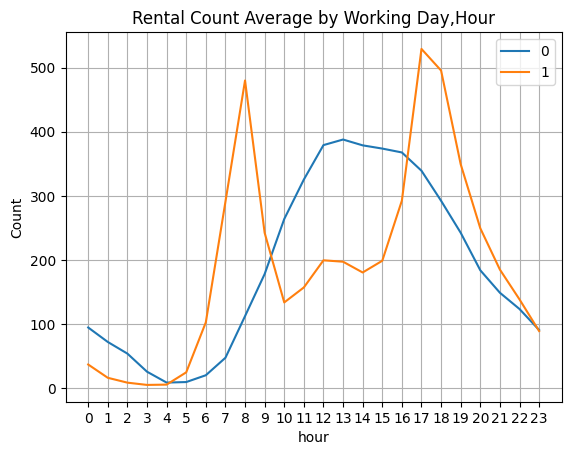

In [29]:
for workingday in average_workingday_hour.index.levels[0]:
    #print (year)
    #print(average_year_month[year])
    plt.plot(average_workingday_hour[workingday].index,average_workingday_hour[workingday],label=workingday)

plt.legend()
plt.xlabel('hour')
plt.ylabel('Count')
plt.xticks(np.arange(24))
plt.grid(True)
plt.title('Rental Count Average by Working Day,Hour')

In [30]:
df.dtypes

,0
datetime,datetime64[ns]
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [31]:
# Save all data
df.to_csv(file_dir+'bike_all.csv',index=False,
          columns=columns)

## Training and Validation Set
### Target Variable as first column followed by input features
### Training, Validation files do not have a column header

In [32]:
# Training = 70% of the data
# Validation = 30% of the data
# Randomize the entire datset
np.random.seed(5)
l = list(df.index)
np.random.shuffle(l)
df = df.iloc[l]

In [33]:
list(df)

['datetime',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'casual',
 'registered',
 'count',
 'year',
 'month',
 'day',
 'dayofweek',
 'hour']

In [34]:
columns = df.columns

In [35]:
rows = df.shape[0]
train = int(.7 * rows)
test = int(.3 * rows)

In [36]:
rows, train, test

(10886, 7620, 3265)

In [37]:
list(columns)

['datetime',
 'season',
 'holiday',
 'workingday',
 'weather',
 'temp',
 'atemp',
 'humidity',
 'windspeed',
 'casual',
 'registered',
 'count',
 'year',
 'month',
 'day',
 'dayofweek',
 'hour']

In [38]:
# Write Training Set
df[:train].to_csv(file_dir+'bike_train.csv'
                          ,index=False,header=False
                          ,columns=columns)

#train - 0.7 (splits the dataset to 70%)
#df[:train] - from record index 0 to 69 - is selected - check records

In [39]:
# Write Validation Set
df[train:].to_csv(file_dir+'bike_validation.csv'
                          ,index=False,header=False
                          ,columns=columns)

In [40]:
# Test Data has only input features
df_test.to_csv(file_dir+'bike_test.csv',index=False)

In [41]:
','.join(columns)

'datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,hour'

In [42]:
# Write Column List
with open(file_dir+'bike_train_column_list.txt','w') as f:
    f.write(','.join(columns))

In [45]:
# checking checkin after change in repo visibility
# test
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,hour
3650,2011-09-03 00:00:00,3,0,0,2,26.24,30.305,73,7.0015,22,65,87,2011,9,3,5,0
8909,2012-08-13 14:00:00,3,0,1,1,32.80,34.850,33,7.0015,85,163,248,2012,8,13,0,14
4623,2011-11-05 17:00:00,4,0,0,1,15.58,19.695,40,11.0014,100,234,334,2011,11,5,5,17
8818,2012-08-09 19:00:00,3,0,1,1,32.80,37.880,55,12.9980,90,533,623,2012,8,9,3,19
1640,2011-04-14 06:00:00,2,0,1,1,13.94,17.425,76,7.0015,4,66,70,2011,4,14,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3046,2011-07-15 20:00:00,3,0,1,1,28.70,32.575,51,15.0013,92,251,343,2011,7,15,4,20
9917,2012-10-17 14:00:00,4,0,1,2,22.96,26.515,43,11.0014,82,188,270,2012,10,17,2,14
4079,2011-10-02 00:00:00,4,0,0,3,14.76,16.665,93,19.9995,4,43,47,2011,10,2,6,0
2254,2011-06-01 20:00:00,2,0,1,2,30.34,35.605,79,16.9979,23,233,256,2011,6,1,2,20


Below is not part of the course material.

# Task
Provide Git commands to create a remote repository, add it as an origin to a local repository with a development branch, commit local changes, and push the code to the remote repository.

## Create a remote repository

### Subtask:
Provide instructions on how to create an empty repository on a hosting platform (e.g., GitHub).


## Add remote origin

### Subtask:
Provide the Git command to add the remote repository as an origin to your local repository.


**Reasoning**:
Provide the Git command to add the remote repository as an origin to the local repository and verify it.



In [43]:
# !git remote add origin git@github.com:emailtosanj/Introduction_to_AI_on_cloud.git
# !git remote -v

## Commit changes

### Subtask:
Provide the Git commands to stage and commit your local changes.


**Reasoning**:
Stage all local changes and commit them with a descriptive message.



In [44]:
# git commit -m ""